In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# 2 ressonadores acoplados indutivamente

Posições dos picos: [4.8987976  4.93186373]


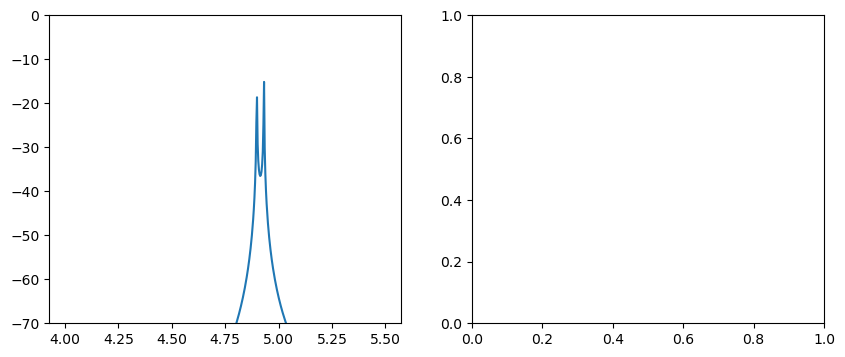

In [14]:
data = np.loadtxt('S21 dois ressoanadores acoplados - produzido na china.txt').T

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(data[0],data[1])
ax[0].set_ylim(-70,0)

#################################################
# Encontrar todos os picos
peaks, _ = find_peaks(data[1])

# Ordenar os picos pela altura
indices_maiores = peaks[np.argsort(data[1][peaks])[-2:]]

# Posições dos dois maiores picos
x_picos = data[0][indices_maiores]
y_picos = data[1][indices_maiores]

print("Posições dos picos:", x_picos)


In [34]:
f_ghz=4.9# + 0.014 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=np.array([7.267])*1e-15 #F
l= 12*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

array([-0.01745505])

In [35]:

indexes = [(0,1),(1,0)]
ALG = -np.zeros((2,2))

n = 0
for i in range(0,1):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1
n = 0
for i in range(1,2):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1

diagonal = f_ghz*np.ones(6)
H = -ALG
np.fill_diagonal(H,diagonal)

hexagon_eigenv = np.sort(np.linalg.eigvals(H))
print(H, hexagon_eigenv)

[[4.9        0.01745505]
 [0.01745505 4.9       ]] [4.88254495 4.91745505]


(4.8, 5.0)

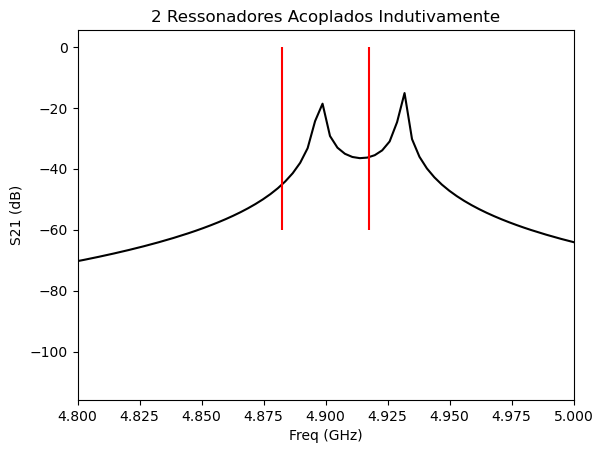

In [39]:
plt.plot(data[0],data[1], 'k')
plt.vlines(hexagon_eigenv,-60, 0, 'r')
plt.xlabel('Freq (GHz)')
plt.ylabel('S21 (dB)')
plt.title('2 Ressonadores Acoplados Indutivamente')

plt.xlim(4.8,5)

# 3 ressonadores acoplamento indutivo

Posições dos picos: [13.91702838 14.17345576]


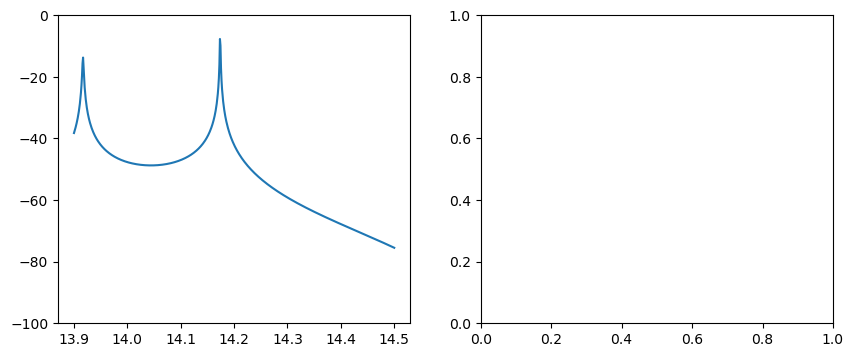

In [86]:
data3 = np.loadtxt('S21 3 ressonadores acopplamento indutivo segundo modo.txt').T

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(data3[0],data3[1])
ax[0].set_ylim(-100,0)

#################################################
# Encontrar todos os picos
peaks, _ = find_peaks(data3[1])

# Ordenar os picos pela altura
indices_maiores = peaks[np.argsort(data3[1][peaks])[-3:]]

# Posições dos dois maiores picos
x_picos = data3[0][indices_maiores]
y_picos = data3[1][indices_maiores]

print("Posições dos picos:", x_picos)


In [108]:
f_ghz=14.3 - 0.3# - 0.214 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=np.array([6.58, 6.57, 6.84])*1e-15 + 2e-15 #F
l= 8.32*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

array([-0.08492647, -0.08482749, -0.0875    ])

In [109]:

indexes = [(0,1),(1,2),(2,0),(1,0),(2,1),(0,2)]
ALG = -np.zeros((3,3))

n = 0
for i in range(0,3):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1
n = 0
for i in range(3,6):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1

diagonal = f_ghz*np.ones(6)
H = -ALG
np.fill_diagonal(H,diagonal)

hexagon_eigenv = np.sort(np.linalg.eigvals(H))
print(H, hexagon_eigenv)

[[14.          0.08492647  0.0875    ]
 [ 0.08492647 14.          0.08482749]
 [ 0.0875      0.08482749 14.        ]] [13.91249905 13.91599232 14.17150863]


(13.8, 14.5)

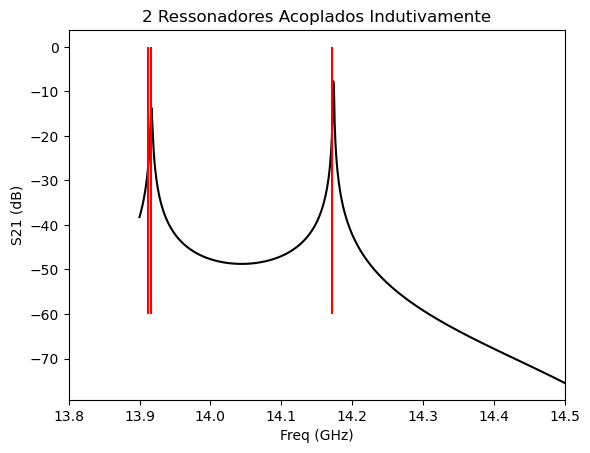

In [110]:
plt.plot(data3[0],data3[1], 'k')
plt.vlines(hexagon_eigenv,-60, 0, 'r')
plt.xlabel('Freq (GHz)')
plt.ylabel('S21 (dB)')
plt.title('2 Ressonadores Acoplados Indutivamente')

plt.xlim(13.8,14.5)